**Segmented Regression Analysis — NSQIP**

This section demonstrates segmented regression on a sample of NSQIP data to evaluate the effect of wRVU revaluation on operative times and procedural volumes. Using fake data for illustration purposes.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('nsqip_cleaning')

from nsqip_segmented_lr import (
    fit_segmented_slope_only, evaluate_breakpoints_slope_only,
    fit_segmented_level_slope, evaluate_breakpoints_level_slope,
    get_line_color, plot_specific_cpts_single_model, plot_single_cpt,
    build_design_matrix, get_prediction_ci,
    REFERENCE_TIMES, CPT_GROUPS
)

In [11]:
# ## 1. Load and prepare fake data

df = pd.read_csv('sample_data/nsqip_sample_data.csv')
df['CPT'] = df['CPT'].astype(str).str.strip()
print(f"Loaded {len(df):,} rows")

cpt = '12345'
break_years = [2007, 2010, 2012]

optime_data = df[df['CPT'] == cpt][['PUFYEAR', 'OPTIME']].copy()
optime_data.columns = ['YEAR', 'VALUE']
optime_data = optime_data.dropna()

volume_data = df[df['CPT'] == cpt].groupby('PUFYEAR').size().reset_index()
volume_data.columns = ['YEAR', 'count']
total_per_year = df.groupby('PUFYEAR').size().reset_index()
total_per_year.columns = ['YEAR', 'total_cases']
volume_data = volume_data.merge(total_per_year, on='YEAR')
volume_data['VALUE'] = volume_data['count'] / volume_data['total_cases'] * 100

optime_dict = {cpt: optime_data}
volume_dict = {cpt: volume_data}

reval_map = {cpt: break_years}
direction_map = {cpt: {2007: 'increase', 2010: 'increase', 2012: 'decrease'}}


Loaded 500,000 rows


In [12]:
# 3. Fit All Four Models

# Operative time — both models
result_optime_slope = evaluate_breakpoints_slope_only(optime_data, cpt, break_years, 'VALUE', 'Operative Time')
result_optime_level = evaluate_breakpoints_level_slope(optime_data, cpt, break_years, 'VALUE', 'Operative Time')

# Volume — both models
result_volume_slope = evaluate_breakpoints_slope_only(volume_data, cpt, break_years, 'VALUE', 'Volume')
result_volume_level = evaluate_breakpoints_level_slope(volume_data, cpt, break_years, 'VALUE', 'Volume')

# Print comparison table
print(f"\n{'='*70}")
print(f"MODEL COMPARISON — CPT {cpt}")
print(f"{'='*70}")
print(f"{'Outcome':<20} {'Model':<15} {'F-test p':<10} {'R²':<10} {'AIC':<10} {'BIC':<10}")
print("-"*70)
for name, r in [('Operative Time', result_optime_slope), ('Operative Time', result_optime_level),
                 ('Volume', result_volume_slope), ('Volume', result_volume_level)]:
    model_type = r['Model_Type']
    print(f"{name:<20} {model_type:<15} {r['F_Pvalue']:.4f}     {r['R2_Segmented']:.4f}    {r['AIC']:.1f}    {r['BIC']:.1f}")


MODEL COMPARISON — CPT 12345
Outcome              Model           F-test p   R²         AIC        BIC       
----------------------------------------------------------------------
Operative Time       Slope Only      0.1958     0.0001    442039.3    442082.9
Operative Time       Level + Slope   0.0595     0.0003    442037.9    442107.7
Volume               Slope Only      0.0337     0.7974    44.1    48.6
Volume               Level + Slope   0.2657     0.7979    50.1    57.2


In [13]:
# 4. Detailed Results — Operative Time

print(f"\n{'='*60}")
print(f"OPERATIVE TIME — DETAILED PARAMETER ESTIMATES")
print(f"{'='*60}")

for model_name, result in [('Slope Only', result_optime_slope), ('Level + Slope', result_optime_level)]:
    print(f"\n─── {model_name} ───")
    print(f"  Pre-Slope: {result['Pre_Slope']:+.4f} min/yr")
    print(f"  F-test p = {result['F_Pvalue']:.4f} {'*' if result['F_Pvalue'] < 0.05 else '(n.s.)'}")
    print(f"  R²: {result['R2_Simple']:.4f} → {result['R2_Segmented']:.4f}")
    print(f"  AIC: {result['AIC']:.1f}  BIC: {result['BIC']:.1f}")
    
    if 'Level_Changes' in result and isinstance(result['Level_Changes'], dict):
        print(f"  Level Changes:")
        for by, change in result['Level_Changes'].items():
            pval = result['Level_Pvalues'][by]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            print(f"    {by}: {change:+.2f} min {sig} (p={pval:.4f})")
    
    print(f"  Slope Changes:")
    for by, change in result['Slope_Changes'].items():
        pval = result['Slope_Pvalues'][by]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"    {by}: {change:+.2f} min/yr {sig} (p={pval:.4f})")



OPERATIVE TIME — DETAILED PARAMETER ESTIMATES

─── Slope Only ───
  Pre-Slope: +0.0623 min/yr
  F-test p = 0.1958 (n.s.)
  R²: 0.0000 → 0.0001
  AIC: 442039.3  BIC: 442082.9
  Slope Changes:
    2007: +0.21 min/yr  (p=0.6999)
    2010: -0.87 min/yr  (p=0.0682)
    2012: +0.67 min/yr * (p=0.0377)

─── Level + Slope ───
  Pre-Slope: -1.7956 min/yr
  F-test p = 0.0595 (n.s.)
  R²: 0.0000 → 0.0003
  AIC: 442037.9  BIC: 442107.7
  Level Changes:
    2007: +3.37 min * (p=0.0134)
    2010: -0.82 min  (p=0.4373)
    2012: -0.23 min  (p=0.8616)
  Slope Changes:
    2007: +2.13 min/yr * (p=0.0174)
    2010: -0.64 min/yr  (p=0.4808)
    2012: +0.38 min/yr  (p=0.6461)


In [14]:
# 5. Detailed Results — Procedural Volume

print(f"\n{'='*60}")
print(f"PROCEDURAL VOLUME — DETAILED PARAMETER ESTIMATES")
print(f"{'='*60}")

for model_name, result in [('Slope Only', result_volume_slope), ('Level + Slope', result_volume_level)]:
    print(f"\n─── {model_name} ───")
    print(f"  Pre-Slope: {result['Pre_Slope']:+.4f} pp/yr")
    print(f"  F-test p = {result['F_Pvalue']:.4f} {'*' if result['F_Pvalue'] < 0.05 else '(n.s.)'}")
    print(f"  R²: {result['R2_Simple']:.4f} → {result['R2_Segmented']:.4f}")
    print(f"  AIC: {result['AIC']:.1f}  BIC: {result['BIC']:.1f}")
    
    if 'Level_Changes' in result and isinstance(result['Level_Changes'], dict):
        print(f"  Level Changes:")
        for by, change in result['Level_Changes'].items():
            pval = result['Level_Pvalues'][by]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            print(f"    {by}: {change:+.4f} pp {sig} (p={pval:.4f})")
    
    print(f"  Slope Changes:")
    for by, change in result['Slope_Changes'].items():
        pval = result['Slope_Pvalues'][by]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"    {by}: {change:+.4f} pp/yr {sig} (p={pval:.4f})")



PROCEDURAL VOLUME — DETAILED PARAMETER ESTIMATES

─── Slope Only ───
  Pre-Slope: -0.1188 pp/yr
  F-test p = 0.0337 *
  R²: 0.6135 → 0.7974
  AIC: 44.1  BIC: 48.6
  Slope Changes:
    2007: +0.0964 pp/yr  (p=0.5332)
    2010: +0.3830 pp/yr  (p=0.2069)
    2012: -0.7691 pp/yr * (p=0.0189)

─── Level + Slope ───
  Pre-Slope: +0.0113 pp/yr
  F-test p = 0.2657 (n.s.)
  R²: 0.6135 → 0.7979
  AIC: 50.1  BIC: 57.2
  Level Changes:
    2007: -0.2759 pp  (p=0.4658)
    2010: -0.1543 pp  (p=0.8139)
    2012: -0.0945 pp  (p=0.8501)
  Slope Changes:
    2007: +0.0221 pp/yr  (p=0.9430)
    2010: +0.3953 pp/yr  (p=0.2006)
    2012: -0.8368 pp/yr *** (p=0.0000)


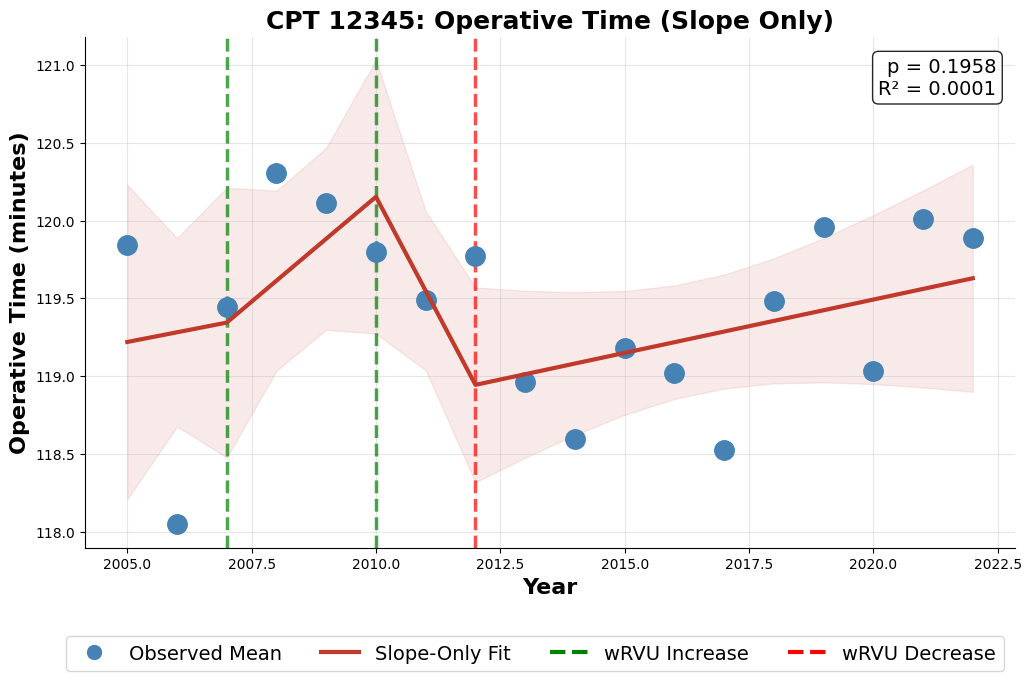

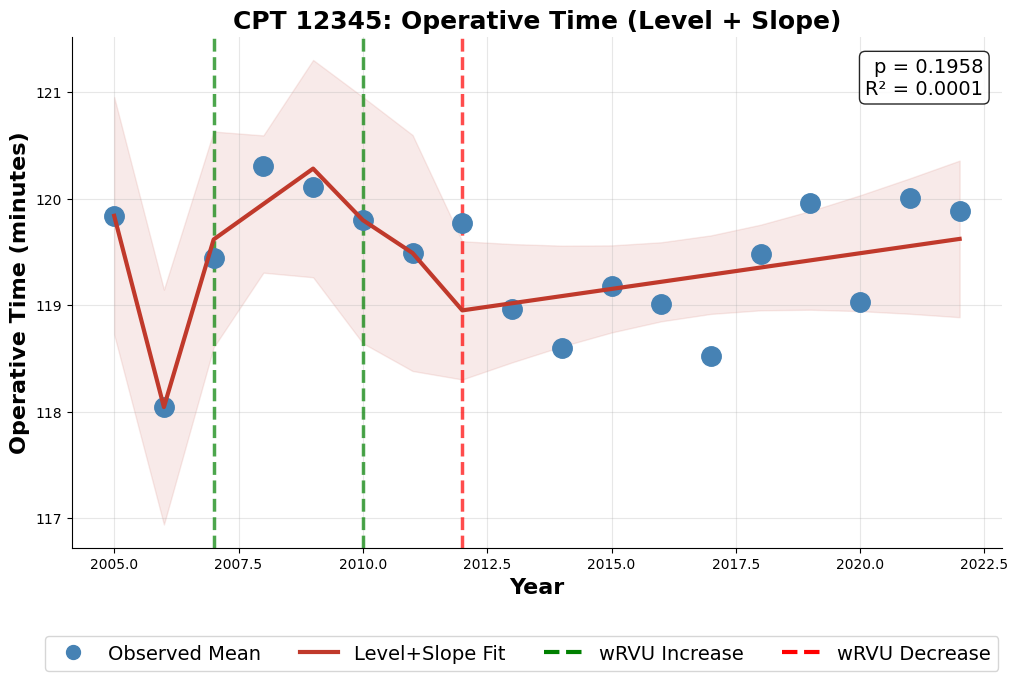

In [15]:
# 6. Plot — Operative Time

optime_df = pd.DataFrame([result_optime_slope, result_optime_level])

# Slope-only plot
plot_single_cpt(
    optime_dict, optime_df, reval_map, direction_map,
    "Operative Time (Slope Only)", "Operative Time (minutes)",
    "demo_optime_slope.svg", cpt,
    model_type='slope_only', show_ci=True
)

# Level+slope plot
plot_single_cpt(
    optime_dict, optime_df, reval_map, direction_map,
    "Operative Time (Level + Slope)", "Operative Time (minutes)",
    "demo_optime_level.svg", cpt,
    model_type='level_slope', show_ci=True
)

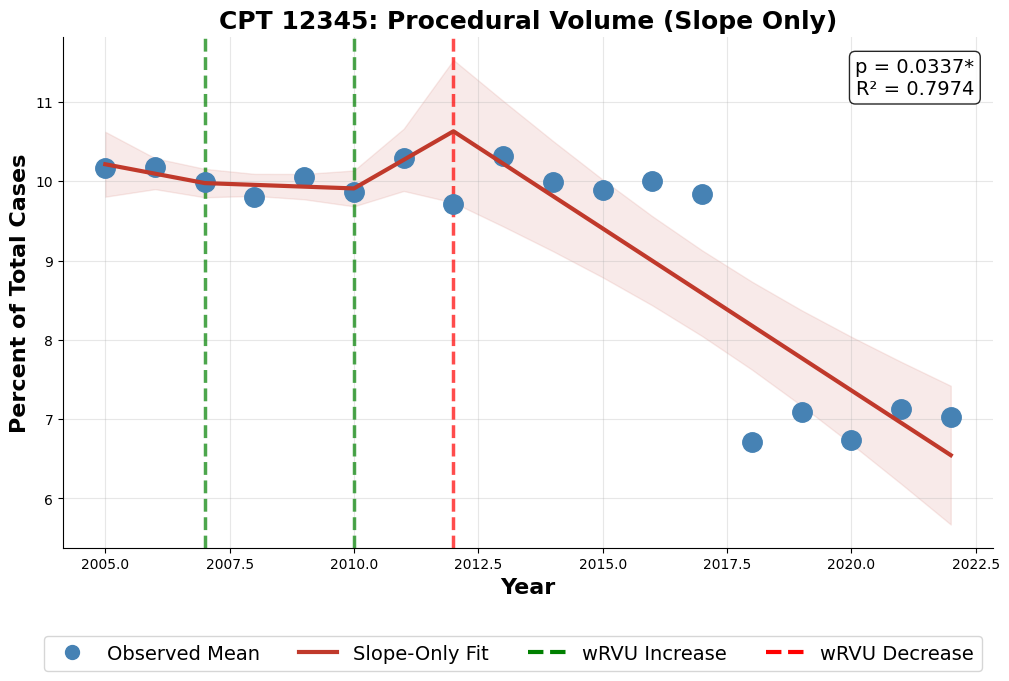

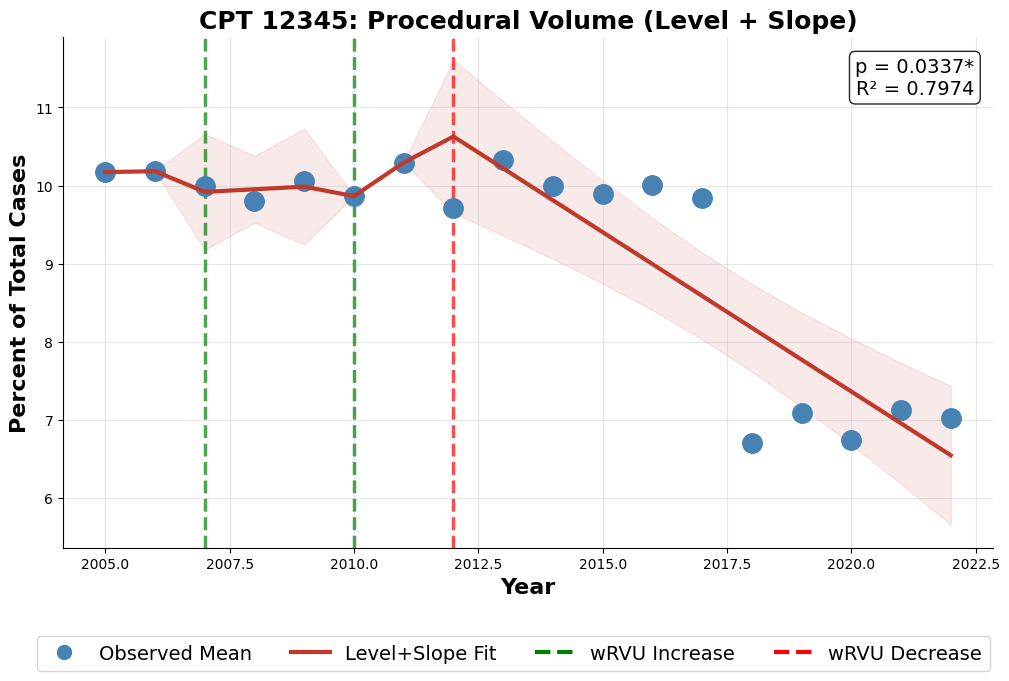

In [16]:
# 7. Plot — Procedural Volume

volume_df = pd.DataFrame([result_volume_slope, result_volume_level])

plot_single_cpt(
    volume_dict, volume_df, reval_map, direction_map,
    "Procedural Volume (Slope Only)", "Percent of Total Cases",
    "demo_volume_slope.svg", cpt,
    model_type='slope_only', show_ci=True
)

plot_single_cpt(
    volume_dict, volume_df, reval_map, direction_map,
    "Procedural Volume (Level + Slope)", "Percent of Total Cases",
    "demo_volume_level.svg", cpt,
    model_type='level_slope', show_ci=True
)


In [17]:
# 8. Takeaway

print(f"Operative time: F-test p = {result_optime_slope['F_Pvalue']:.4f} — "
      f"{'Responds' if result_optime_slope['F_Pvalue'] < 0.05 else 'Does NOT respond'} to wRVU changes")
print(f"Volume:         F-test p = {result_volume_slope['F_Pvalue']:.4f} — "
      f"{'Responds' if result_volume_slope['F_Pvalue'] < 0.05 else 'Does NOT respond'} to wRVU changes")

# Compare AIC
if result_optime_level['BIC'] < result_optime_slope['BIC']:
    print(f"Operative time: Level+Slope preferred by BIC")
else:
    print(f"Operative time: Slope Only preferred by BIC")

if result_volume_level['BIC'] < result_volume_slope['BIC']:
    print(f"Volume: Level+Slope preferred by BIC")
else:
    print(f"Volume: Slope Only preferred by BIC")

# (not reflective of our actual results, where Level+Slope was favored for Operative Time)

Operative time: F-test p = 0.1958 — Does NOT respond to wRVU changes
Volume:         F-test p = 0.0337 — Responds to wRVU changes
Operative time: Slope Only preferred by BIC
Volume: Slope Only preferred by BIC


**Mixed Effects**